This notebook does the Least-Component Analysis of a dataset.

The data should be in "datasets/true_datasets" and include the matrix of taxon abundances as a np.array() and include the taxonomic tags in "datasets/taxonomic_tags".

All outputs are saved in the directory "out" and will include the dataset name. Figures are saved to "out/figures".

The code does the following:
1) Import the dataset.
2) Filter out rare taxa according to criterion ('occupancy' threshold or 'number' of most abundant taxa) and order the rest by mean abundance.
3) Calculate correlation matrix. Diagonalize to get eigenvalues and eigenvectors.
4) Compute null model and null eigenvalue distribution. If the MCMC version of the null (relative-abundance aware) already exists, load it. Else if the eigenvalues from the basic shuffling null already exist load them. Else, do the basic shuffling null.
5) Get low and high variance modes comparing to the null of the bulk distribution.
6) Measure the similarity of LCs.
7) Plot the coupling network for the taxa with strongest couplings.

## Load Functions and Libraries

In [1]:
import numba
from numba import jit,njit
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scipy.integrate as integrate
import scipy as sp
import scipy
import matplotlib.colors as colors
import pickle
import os
import time
import matplotlib.patches as patches

geometric_changes=True

In [2]:
def plot_matrix(matrix,cmap = 'RdBu',max_value=None,min_value=None,aspect=None,tight_layout=True,figsize=None,
               xticks = [],x_ticklabels = [],x_orientation=0,x_alignment='center',
                yticks = [],y_ticklabels = [],title=None,
               xlabel=None,ylabel=None,
                set_log_xscale=False,set_log_yscale=False,scale=None,
               cbar_label = None,x_fontsize=10,y_fontsize=10,
               savefig=False,out_dir='',data_name = '',
               draw_special_diagonal=False,diagonal_color='k',format='pdf'):

    if max_value==None:
        max_value = 1.1*np.max(matrix)
    if min_value==None:
        min_value = 1.1*np.min(matrix)
    norm_value = (colors.TwoSlopeNorm(vcenter=0,vmin=min_value,vmax=max_value) if cmap=='RdBu' else None)
    if scale=='log': norm_value='log'
    fig,ax = plt.subplots(figsize=figsize)
    heatmap = ax.imshow(
               matrix,
               cmap=cmap,
               aspect=aspect,
               norm=norm_value,
               vmax = (max_value if cmap=='Reds' or cmap=='Blues' else None),
                       )
    cbar = fig.colorbar(heatmap,label=cbar_label,ax=ax, fraction=0.046, pad=0.04)
    if draw_special_diagonal ==True:
        for i in range(min(np.shape(matrix)[0],np.shape(matrix)[1])):
            rect = patches.Rectangle(
                (i - 0.5, i - 0.5),  # bottom-left corner (cell boundaries in imshow coordinates)
                1, 1,                # width, height (one cell)
                facecolor="black",
                edgecolor="none",
                zorder=3             # draw above the image
            )
            ax.add_patch(rect)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.set_yticklabels(y_ticklabels,fontsize=y_fontsize)
    ax.set_xticklabels(x_ticklabels,rotation=x_orientation,ha=x_alignment,
                      fontsize=x_fontsize)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    if set_log_xscale == True:
        ax.set_xscale('log')
    if set_log_yscale==True:
        ax.set_yscale('log')
    if tight_layout==True:
        plt.tight_layout()
    if savefig==True:
        plt.savefig(os.path.join(out_dir,data_name)+str('.{}'.format(format)),format=format,dpi=200,transparent=True)
    plt.show()  

    return

In [3]:
def sort_dataset_by_mean_abundance(full_dataset,family_tags,which_mean='when_present',
                                  return_argsort = False,
                                  entropies=None):
    '''
    Data is normalized into relative abundances at the end, just in case.
    '''
    means = np.mean(full_dataset,axis=0)
    above_threshold = (full_dataset>means[None,:])
    times_above_threshold = np.sum(above_threshold,axis=0)
    new_means = np.sum(full_dataset*above_threshold, #take mean only of the data where the samples are above their mean value.
                        axis=0)/times_above_threshold
    times_present = np.sum(full_dataset>0,axis=0)
    fig,ax = plt.subplots()
    ax.scatter(means,new_means)
    ax.set_xlabel('Mean')
    ax.set_ylabel('Mean when present')
    plt.show()
    
    maxes = np.max(full_dataset,axis=0) #maximum relative abundance of each species
    ''' Sort using total mean or mean when present (new_means) '''
    if which_mean=='when_present':
        print('Sorting by mean when present')
        indices_by_mean_abundance = np.flip(np.argsort(new_means))
    elif which_mean=='maxes':
        print('Sorting by maximum value')
        indices_by_mean_abundance = np.flip(np.argsort(maxes))
    elif which_mean=='means':
        print('Sorting by mean (both present and absent)')
        indices_by_mean_abundance = np.flip(np.argsort(means))
    elif which_mean=='number_appearances':
        print('Sorting by number of appearances')
        indices_by_mean_abundance = np.flip(np.argsort(times_present))
    elif which_mean=='entropies':
        print('Sorting by entropy')
        indices_by_mean_abundance = np.flip(np.argsort(entropies))
    else:
        print('No proper sorting preference given')
    
    full_dataset = full_dataset[:,indices_by_mean_abundance]
    family_tags = [family_tags[tag] for tag in indices_by_mean_abundance]
    
    # full_dataset =full_dataset/np.sum(full_dataset,axis=1)[:,None] #renormalize back to 1 just in case, even if it should be supefluous.
    print('Most common strains: \n',family_tags[:6])
    
    how_many_experimental_samples,how_many_species = np.shape(full_dataset)

    if return_argsort ==True:
        output = (full_dataset,family_tags,how_many_experimental_samples,how_many_species,indices_by_mean_abundance)
    else:
        output = (full_dataset,family_tags,how_many_experimental_samples,how_many_species)
    return output

In [4]:
''' Calculate the Shannon Entropy for the marginal distribution of each species, then select which species to keep as those
that have the highest entropy. 

Species with low entropy in their marginal distribution are likely to be species that most of the time have a low abundance and rarely have a 
very high abundance, so we wanna rule them out. '''

from scipy.stats import entropy as shannon_entropy

def calculate_shannon_entropies(full_dataset_copy,
                               z_scores = True):

    full_dataset = np.copy(full_dataset_copy)

    ''' Set 0s in the dataset as abundances 2 orders of mangitude below the minimum non-zero abundance in the dataset 
    This makes 0s appear in the distribution, and ensures that the peak of absences is counted towards the entropy of the distribution.
    '''
    min_dataset = np.min(full_dataset[full_dataset>0])
    bin_min = np.log10(min_dataset)-2
    full_dataset[full_dataset==0] = 10**bin_min

    ''' If z_scores == True,
    rescaled abundances as y---> z = (y-mean(y))/std(y), where y=log10(x) 
    such that we calculate the entropy of a taxon's AFD and consider its distribution of rescaled abundance changes, independently of whether it 
    is an overall high- or low-abundance species.
    '''
    full_dataset = np.log10(full_dataset)
    if z_scores ==True:
        means = np.mean(full_dataset,axis=0)[None,:]
        stds = np.std(full_dataset,axis=0)[None,:]
        full_dataset = (full_dataset-means)/stds
    full_dataset = 10**full_dataset

    

    shannon_entropies = []
    # marginal_bins = np.linspace(-10.1,0,100) #in log-space
    marginal_bins = np.linspace(bin_min,np.log10(np.max(full_dataset)*1.05),100)
    dbin = marginal_bins[1]-marginal_bins[0]
    bin_centers = marginal_bins[:-1]+dbin/2
    for s in range(np.shape(full_dataset)[1]):
        marginal_abundances = np.copy(full_dataset[:,s])
        marginal_abundances[marginal_abundances==0] = 10**bin_min
        marginal_log_abundances = np.log10(marginal_abundances)
    
        # print(marginal_log_abundances)
        
        marginal_distribution,bins = np.histogram(marginal_log_abundances,bins = marginal_bins,density=True)
    
        # fig,ax = plt.subplots()
        # ax.bar(bin_centers,marginal_distribution*dbin,
        #       width=dbin)
        # plt.show()
        
        entropy_val = shannon_entropy(marginal_distribution)
        shannon_entropies.append(entropy_val)
    
    shannon_entropies = np.array(shannon_entropies)
    return shannon_entropies

In [5]:
def Marchenko_Pastur_significance_threshold(lam,var):
    sqrt = np.sqrt(lam)
    out1 = var*(1-sqrt)**2
    out2 = var*(1+sqrt)**2
    return (out1,out2)
    
def Marchenko_Pastur_distribution(lambda_min,lambda_max,r,var):
    x_vector = np.linspace(lambda_min,lambda_max,10000)
    dx = x_vector[1]-x_vector[0]
    pdf = 1/(2*np.pi*var) * np.sqrt((lambda_max-x_vector)*(x_vector-lambda_min))/(r*x_vector)
    return x_vector,pdf

def Marchenko_Pastur_distribution(lambda_min,lambda_max,r,var):
    x_vector = np.linspace(lambda_min,lambda_max,10000)
    dx = x_vector[1]-x_vector[0]
    pdf = 1/(2*np.pi*var) * np.sqrt((lambda_max-x_vector)*(x_vector-lambda_min))/(r*x_vector)
    return x_vector,pdf



In [6]:
import networkx as nx

In [7]:
''' Plot the interaction network using the precision matrix as an adjacency matrix '''
import matplotlib as mpl
''' Plot the interaction network using the precision matrix as an adjacency matrix '''
def plot_weighted_graph(adj_matrix,node_labels=None,write_labels = True,
                       label_colors=None,
                       colored_labels = None,
                        maxvalue = None,minvalue=None,
                        figtitle = None,figsize=(7,6),dataset_name = '',
                        node_sizes = None,pos= None,node_size_with_mean_abundance = True,
                       figname = None):
    if figname==None: figname = 'interaction_network.{}.png'.format(dataset_name)
    """
    Plots a weighted graph from an adjacency matrix.
    Positive weights -> blue edges
    Negative weights -> red edges
    Diagonal entries are ignored.

    Parameters:
    adj_matrix (np.ndarray): Square adjacency matrix with weights.
    """
    if maxvalue==None:
        maxvalue = np.max(adj_matrix)
    if minvalue==None:
        minvalue = np.min(adj_matrix)
    
    # Ensure it's a NumPy array
    A = np.array(adj_matrix, dtype=float)

    # Ignore diagonal entries, just in case
    np.fill_diagonal(A, 0)

    n = A.shape[0]

    if node_labels is None:
        node_labels = np.arange(n)
    elif len(node_labels) != n:
        raise ValueError("Length of node_labels must match size of adjacency matrix")


    # Create a NetworkX graph
    G = nx.DiGraph() if not np.allclose(A, A.T) else nx.Graph()

    # Add weighted edges
    n = A.shape[0]
    for i in range(n):
        for j in range(n):
            if A[i, j] != 0:
                G.add_edge(i,j, weight=A[i, j])
                
    # Create dictionary of node labels and colors
    node_labels_dict = {}
    label_colors = {}# {'k':[],'tab:orange':[]}
    label_color_list = []
    node_color_list = []
    
    for i,label in enumerate(node_labels):
        node_labels_dict[i] = label
        label_colors[i] = 'black' if label not in colored_labels else 'bisque'
        label_color_list.append('black' if label not in colored_labels else 'bisque')
        node_color_list.append('lightgray' if label not in colored_labels  else 'tab:orange')
        
    

    # Determine edge colors and weights
    pos_edges = [(u, v, d['weight']) for u, v, d in G.edges(data=True) if d['weight'] > 0]
    neg_edges = [(u, v, d['weight']) for u, v, d in G.edges(data=True) if d['weight'] < 0]

    if pos == None:
        pos = nx.circular_layout(G) #makes the network circular, which is good to keep the nodes always in the same place
        # pos = nx.arf_layout(G,scaling=1) #like spring layout, but in principle avoids clutttering
        # pos = nx.spiral_layout(G)
        # pos = nx.graphviz_layout(G)


    
    ''' Bring nodes in or out sequentially so that there is more space inbetween them '''
    ### In general, alterante taxa between the inner and outer circle
    for node in pos.keys():
        x,y = pos[node]
        if node%2==0: #node is even
            x *= 1.1; y *= 1.1 #Use 1.6 for Estrela dataset
            pos[node] = (x,y)
        else: #node is odd
            theta = (1/len(pos))*2*np.pi #angle between consecutive species #Use 1/len(pos)*2*np.pi for Estrela dataset
            rotation = np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]])
            x,y = rotation@pos[node].T
            x *= 0.7; y *= 0.7 #use 0.7 for Estrela Dataset
            pos[node] = (x,y)

    plt.figure(figsize=figsize)
    

    
    if node_size_with_mean_abundance:
        edge_colors = []
        if node_sizes is None:
            node_sizes = 400
            edge_colors = 'k'
        else:
            new_node_sizes = []
            mean_size = np.mean(node_sizes)
            for i in range(len(node_labels)):
                new_node_sizes.append(node_sizes[i]/mean_size*400)
                if node_sizes[i]>1*mean_size:
                    edge_colors.append('k')
                else:
                    edge_colors.append('white')
            node_sizes = new_node_sizes
        
        nx.draw_networkx_nodes(G, pos, 
                               node_size=node_sizes, 
                               node_color=node_color_list,
                               edgecolors='white',
                               alpha=0.8
                               # linewidths=1
                              )
        nx.draw_networkx_nodes(G, pos, 
                               node_size=10, 
                               node_color=node_color_list,
                               alpha=1
                               # linewidths=1
                              )
    else:
        node_sizes = np.log10(node_sizes) #do log(abundances) so the color scale is more spread out.
        node_colors = (node_sizes-np.min(node_sizes))/(np.max(node_sizes)-np.min(node_sizes)) #between zero and 1
        node_colors = 1-node_colors #such that larger mean abundances leads to smaller color, aka darker.
        nx.draw_networkx_nodes(G, pos, 
                               node_color=np.outer(np.array([1.,1.,1.]),node_colors).T,
                               edgecolors=node_color_list,
                               alpha=1,
                               linewidths=3
                              )
        
    
    # Normalize edge weights for alpha scaling
    all_weights = [abs(d['weight']) for _, _, d in G.edges(data=True)]
    max_w = maxvalue
    min_w = minvalue; print('is min_w negative',min_w<0)

    def get_alpha(weight,min_w,max_w):
        """Scale alpha between 0.2 and 1.0 based on relative magnitude."""
        if weight<0:
            out = 0.0+1.0*(weight/min_w)**1
        else:
            out = 0.0+1.0*(weight/max_w)**1
        return out


    # Draw positive (blue) and negative (red) edges
    print(np.outer(np.array([0.5,0.5,0.5]),np.array([get_alpha(w,min_w,max_w) for _,_,w in neg_edges])).shape)
    nx.draw_networkx_edges(G, pos, edgelist=pos_edges, edge_color='tab:blue', 
                           width= [5*get_alpha(w,min_w,max_w) for _,_,w in pos_edges],
                          alpha = [get_alpha(w,min_w,max_w) for _,_,w in pos_edges])
    
    nx.draw_networkx_edges(G, pos, edgelist=neg_edges, 
                           edge_color = 'tab:red',
                           width= [5*get_alpha(w,min_w,max_w) for _,_,w in neg_edges],
                          alpha = [get_alpha(w,min_w,max_w) for _,_,w in neg_edges]
                          )


    if write_labels == True:
        print(node_labels)
        nx.draw_networkx_labels(G,
                                # label_pos,
                                pos,
                                node_labels_dict,
                                horizontalalignment = 'left',verticalalignment='bottom',
                                font_size=12,bbox = {'fc':'white','ec':'white','lw':0,'pad':0},
                               font_color='black',)
    if figtitle != None:
        plt.title(figtitle)

    cmap = plt.cm.RdBu
    # cmap = plt.cm.Reds
    norm = mpl.colors.TwoSlopeNorm(
        vmin=minvalue,
        vcenter=0,#(maxvalue-minvalue)/2+minvalue,
        vmax=maxvalue
    )
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # required for older matplotlib versions1
    plt.tight_layout()
    cbar = plt.colorbar(sm, shrink=0.5, pad=0.0)
    cbar.set_label(r'$J_{ij}$', rotation=270, labelpad=10)
    if node_size_with_mean_abundance==False:
        ''' Introduce a second colorbar, horizontal, that shows scaling of mean abundances '''
        cmap = plt.cm.Greys
        norm = mpl.colors.Normalize(vmin=np.min(node_sizes),
                                    vmax = np.max(node_sizes))
        sm = mpl.cm.ScalarMappable(cmap=cmap,norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm,shrink=0.5,pad=0.0,location='bottom')
        cbar.set_label(r'log$_{10}$(mean abundance)', labelpad=10)
    plt.axis('off')
    
    plt.show()
    format='svg'
    plt.savefig(os.path.join(out_figures,figname)+'.{}'.format(format),dpi=300,format=format,transparent=True)

    return 

## Load a dataset

The notebook takes 3 inputs:

- Dataset name.
- Data matrix. This is an M by N np.array, with M samples and N taxa, and each entry is the taxon abundance.
- Taxon tags. If not provided, an integer value is used to tag every taxon.

In [8]:
occupancy_threshold = 0.5 #default, unless explicitly stated below
''' Datasets analyzed in the manuscript '''
# dataset_name = 'Grilli.GUT.SRP056641'; discarding_criterion = 'occupancy'; how_many_species_to_take = 10000; is_relative = False #with 66 samples
# dataset_name = 'Grilli.GUT.ERP015450'; discarding_criterion = 'occupancy'; how_many_species_to_take = 10000; is_relative = False #with 195 samples
# dataset_name = 'Grilli.activatedsludge'; discarding_criterion = 'occupancy'; how_many_species_to_take = 10000; is_relative = False 
# dataset_name = 'Grilli.Glacier'; discarding_criterion = 'occupancy'; how_many_species_to_take = 10000; is_relative = False 
# dataset_name = 'Grilli.River'; discarding_criterion = 'occupancy'; how_many_species_to_take = 10000; is_relative = False 
dataset_name = 'Grilli.Soil'; discarding_criterion = 'occupancy'; how_many_species_to_take = 10000; is_relative = False 
# dataset_name = 'Grilli.Oral'; discarding_criterion = 'occupancy'; how_many_species_to_take = 10000; is_relative = False 
# dataset_name = 'Grilli.Lake'; discarding_criterion = 'occupancy'; how_many_species_to_take = 10000; is_relative = False 
# dataset_name = 'Estrella_full'; discarding_criterion = 'number'; how_many_species_to_take = 14; is_relative = True
# dataset_name = 'Goldford.Citrate'; discarding_criterion = 'number'; how_many_species_to_take = 10000; is_relative =True #already filtered
# dataset_name = 'Goldford.Glucose'; discarding_criterion = 'number'; how_many_species_to_take = 10000; is_relative = True #already filtered
# dataset_name = 'Goldford.Leucine'; discarding_criterion = 'number'; how_many_species_to_take = 10000; is_relative = True #already filtered. Has no LCs, so code will fail beyond the first few sections.

absolute_abundances = False
if absolute_abundances: dataset_name = dataset_name+'.absolute_abundances'
input_dir = 'datasets'

out_dir = 'out/{}'.format(dataset_name)
out_figures = out_dir+'/figures'
if os.path.exists('out')==False:
    os.mkdir('out')
    

if os.path.exists(out_dir)==False:
    os.mkdir(out_dir)
if os.path.exists(out_figures)==False:
    os.mkdir(out_figures)

In [9]:
print(dataset_name)

Grilli.Soil


In [10]:
with open(os.path.join(input_dir,'true_datasets/full_dataset.{}.dat'.format(dataset_name)),'rb') as f:
    original_dataset = pickle.load(f) #taxa should be sorted by mean abundance
    M,N_full = np.shape(original_dataset)
    how_many_experimental_samples = M
    print('The original dataset has {} samples and {} species'.format(M,N_full))
    f.close()

''' "Family_tags" is a misnomer that comes from using family-level taxonomic tags for the dataset of Goldford et al. Think it's whatever taxonomic classification you are using for the taxa.'''
with open(os.path.join(input_dir,'taxonomic_tags/family_tags.{}.dat'.format(dataset_name)),'rb') as f:
    original_family_tags = pickle.load(f)
    original_family_tags = [tag.replace(' ','') for tag in original_family_tags]
    original_family_tags = np.array(original_family_tags)
    f.close()


The original dataset has 112 samples and 10468 species


### Check Taylor's Law:

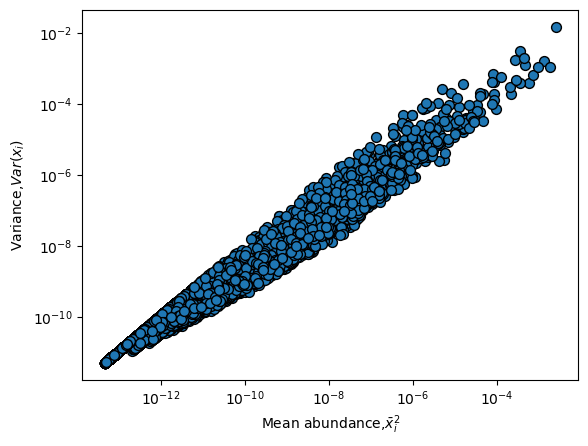

In [11]:
plt.close('all')
fig,ax = plt.subplots()
full_dataset_means = np.mean(original_dataset,axis=0)
full_dataset_var = np.var(original_dataset,axis=0)
ax.scatter(full_dataset_means**2,full_dataset_var,s=50,edgecolor='k')
# ax.scatter(full_dataset_means,full_dataset_var**0.5,s=50,edgecolor='k')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Mean abundance,'+r'$\bar{x}_i^2$')
ax.set_ylabel('Variance,'+r'$Var({x}_i)$')
plt.savefig(os.path.join(out_figures,'taylor_law.{}.png'.format(dataset_name)))

### Calculate occupancies:

In [12]:
presence_threshold = 0 #in general
how_many_times_present = np.sum(original_dataset>presence_threshold,axis=0)
original_occupancy = how_many_times_present/M


In [13]:
print(original_occupancy)

[0.01785714 0.00892857 0.02678571 ... 0.05357143 0.01785714 0.39285714]


## Discard rare taxa according to criterion

In [14]:
full_dataset = np.copy(original_dataset)
include_rest_of_the_world = False #create a single pseudo-species that is the aggregate of all the neglected species
if discarding_criterion=='occupancy':
    print('Discarding by occupancy')
    which_to_take = original_occupancy>occupancy_threshold
    which_not_to_take = original_occupancy<=occupancy_threshold
    how_many_species_to_take = np.sum(which_to_take)

    rest_of_the_world_abus = np.sum(original_dataset[:,which_not_to_take],axis=1)
    
    ''' Keep non-discarded taxa '''
    family_tags = original_family_tags[which_to_take]
    full_dataset = original_dataset[:,which_to_take]
    if include_rest_of_the_world:
        full_dataset = np.hstack((full_dataset,np.array([rest_of_the_world_abus]).T))
        family_tags = list(family_tags)
        family_tags.append('R.o.w')
        family_tags = np.array(family_tags)
        how_many_species_to_take += 1
    cov_data = np.copy(full_dataset)
elif discarding_criterion=='number':
    print('Discarding by number of species')
    ''' Ensure taxa are sorted by mean abundance'''
    full_dataset,family_tags,M,N = sort_dataset_by_mean_abundance(
                                    original_dataset,original_family_tags,which_mean='means',
                                    return_argsort = False,
                                    entropies=None)
    

    rest_of_the_world_abus = np.sum(full_dataset[:,how_many_species_to_take:],axis=1)
    
    ''' Keep non-discarded taxa '''
    full_dataset = full_dataset[:,:how_many_species_to_take]
    family_tags = family_tags[:how_many_species_to_take]
    if include_rest_of_the_world:
        full_dataset = np.hstack((full_dataset,np.array([rest_of_the_world_abus]).T))
        family_tags.append('R.o.w')
        how_many_species_to_take += 1
    print(family_tags)
    cov_data = np.copy(full_dataset)
    
else: print('No proper discarding criterion')


'''
Sort the dataset by mean taxon abundance after filtering out low-occupany species, 
such that leftmost taxon in eigenvectors is the most abundant, by mean abundance.
'''
mean_sorted_taxa = np.flip(np.argsort(np.mean(full_dataset,axis=0)))
if absolute_abundances==False:
    full_dataset = full_dataset[:,mean_sorted_taxa]
    cov_data = cov_data[:,mean_sorted_taxa]
    family_tags = np.array(family_tags)[mean_sorted_taxa]
else:
    ''' Recast taxon orders according to order in relative abundance data. '''
    full_dataset = full_dataset[:,mean_sorted_taxa]
    cov_data = cov_data[:,mean_sorted_taxa]
    family_tags = np.array(family_tags)[mean_sorted_taxa]

with open(os.path.join(out_dir,'mean_sorted_taxa.{}.dat'.format(dataset_name)),'wb') as f:
    pickle.dump(mean_sorted_taxa,f)
    f.close()

    
M,N = np.shape(full_dataset)
print('We consider {} species and {} samples'.format(N,M))
occupancy = np.sum(full_dataset>presence_threshold,axis=0)/M


''' Write filtered dataset to output '''
with open(os.path.join(out_dir,'full_dataset.filtered.{}.dat'.format(dataset_name)),'wb') as f:
    pickle.dump(full_dataset,f)
    f.close()

with open(os.path.join(out_dir,'family_tags.filtered.{}.dat'.format(dataset_name)),'wb') as f:
    simplified_family_tags = np.copy(family_tags)
    pickle.dump(family_tags,f)
    f.close()

''' Rescale cov_data abundances by their standard deviation '''
### The only reason not to subtract the mean is to be able to compute c_\alpha later on.
cov_data_stds = np.std(cov_data,axis=0)
cov_data_means = np.mean(cov_data,axis=0)
cov_data = (cov_data-cov_data_means[None,:])/cov_data_stds[None,:] #z-scored abundances.

Discarding by occupancy
We consider 561 species and 112 samples


## Construct and diagonalize correlation matrix

In [15]:
corr_matrix = np.corrcoef(cov_data.T)

eigvals,eigvects = np.linalg.eigh(corr_matrix)

sorted_indices = np.argsort(eigvals)
''' Sort eigenvalues from smallest to largest '''
eigvals = eigvals[sorted_indices]  #eigenvalues add up to the number of species (aka the number of eigenvalues)
eigvects = eigvects[:,sorted_indices]

In [16]:
with open(os.path.join(out_dir,'eigvals.{}.dat'.format(dataset_name)),'wb') as f:
    pickle.dump(eigvals,f)
    f.close()

with open(os.path.join(out_dir,'eigvects.{}.dat'.format(dataset_name)),'wb') as f:
    pickle.dump(eigvects,f)
    f.close()

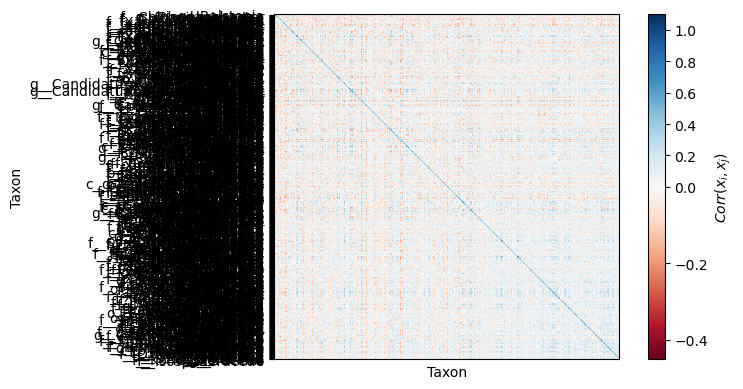

<Figure size 640x480 with 0 Axes>

In [17]:
''' Plot correlation matrix '''
plot_matrix(corr_matrix,cmap = 'RdBu',aspect=None,tight_layout = True,figsize=(8,4),
               xticks = [],yticks = np.arange(len(family_tags[:how_many_species_to_take])),y_ticklabels = family_tags[:how_many_species_to_take],
               xlabel='Taxon',ylabel='Taxon',title=None,
               cbar_label = r'$Corr(x_i,x_j)$',
               savefig=True,out_dir=out_figures,data_name = 'covariance_matrix',
               format='png')
plt.tight_layout()

## Compute or, if available, import the null distribution of eigenvalues

In [18]:
MCMC_eigenvalues = 'datasets/dummy_datasets_MCMC/dummy_eigvals.MCMC.{}.dat'.format(dataset_name)
MCMC_data = 'datasets/dummy_datasets_MCMC/dummy_data.MCMC.{}.dat'.format(dataset_name)
basic_shuffling_eigenvalues = 'datasets/dummy_eigvals_basic_shuffling/random_eigvals.{}'.format(dataset_name)

how_many_shuffles = 100
# how_many_shuffles = 50

print('Checking if MCMC eigenvalues exist...')
if os.path.exists(MCMC_eigenvalues):
    with open(MCMC_eigenvalues,'rb') as f:
        random_eigvals = pickle.load(f)
        f.close()
        random_eigvals = np.array(random_eigvals)
        print('Done. Loaded MCMC null distribution.')
else:
    print('MCMC eigenvalues do not exist. Checking if the MCMC null data exists and recalculating eigenvalues...')
    if os.path.exists(MCMC_data):
        random_eigvals = []
        with open(MCMC_data,'rb') as f:
            full_dummy_data = pickle.load(f)
            f.close()

        a,b = np.shape(full_dummy_data)
        for ran in range(int(round(a/M)+0.01)):
            print('Randmization: {}'.format(ran))
            dummy_data = full_dummy_data[ran*M:(ran+1)*M,:]
            dummy_corr = np.corrcoef(dummy_data.T)
            dummy_eigs,_ = np.linalg.eigh(dummy_corr)
            for eig in dummy_eigs:
                random_eigvals.append(eig) #append eigenvalue of random data.

        random_eigvals = np.array(random_eigvals)
        print('Done. Loaded MCMC null data and recalculated eigenvalues.')
    else:
        print('There is no MCMC data at all. Checking if basic reshuffled data exists...')
        if os.path.exists(basic_shuffling_eigenvalues):
            with open(basic_shuffling_eigenvalues,'rb') as f:
                random_eigvals = pickle.load(f)
                f.close()
                random_eigvals = np.array(random_eigvals)
                print('Done. Loaded basic reshuffled data.')
        else:
            print('There is no known null data for this dataset. Producing null data via sepcies shuffling...')

            keep_pseudocompositional_data = False
            keep_full_dummy = True
            
            full_dummy_dataset = []
            
            random_eigvals = []
            random_eigvals_nonzero = []
            random_eigvects = []
            keep_low_var_eigvects = False
            
            
            
            dummy_data_total_abundances = []
            for i in range(how_many_shuffles):
                if i%10==0:
                    print('Randmization: {}/{}.'.format(i,how_many_shuffles))
                
                ''' For every species, shuffle its abundance accross communities so intespecies correlations are messed up, but do not mix different species '''
                dummy_data = np.copy(full_dataset)
                _1,_2 = np.shape(dummy_data)
                ''' Shuffle community indices for every species, preserving species' marginal distributions. '''
                shuffled_comms = np.arange(_1) #before shuffling
                for j in range(_2): #for every species
                    np.random.shuffle(shuffled_comms) #shuffled community indices
                    dummy_data[:,j] = dummy_data[shuffled_comms,j]
                ''' Rescale dummy data like the true cov_data '''
                which_nonempty = (np.sum(dummy_data,axis=1)>0)
                if keep_pseudocompositional_data:
                    ''' Rescale dummy data such that the total abundance of the community respects the statistics of the true data '''
                    ''' This surely destroys part of the marginal distributions but ensures the dummy data is as compositional as the true data '''
                    dummy_data = dummy_data[which_nonempty,:]/(np.sum(dummy_data,axis=1)[which_nonempty,None]) #Relative abundances if needed
                    dummy_data *= total_community_abundance_mean
                    dummy_data = dummy_data*(1+np.random.normal(0,total_community_abundance_std,np.sum(which_nonempty)))[:,None]
                dummy_data_stds = np.std(dummy_data,axis=0,ddof=1)[None,:] #calculate std of every taxon
                dummy_data_means = np.mean(dummy_data,axis=0)[None,:] #calculate mean of every taxon
            
                if keep_full_dummy == True: 
                    for comm in dummy_data:
                        full_dummy_dataset.append(comm)
            
                total_abundances = np.sum(dummy_data,axis=1)
                for abu in total_abundances:
                    dummy_data_total_abundances.append(abu)         
            
                if np.any(np.isnan(dummy_data))==True:
                    ''' If some dummy species has variance zero, there will be nans in the dataset, so ignore that iteration '''
                    print('NaNs in dummy data in iteration {}'.format(i))
                    pass
                else:
                    dummy_corr = np.corrcoef(dummy_data.T)
                    try:
                        dummy_eigs,_ = np.linalg.eigh(dummy_corr)
                    except:
                        print('Infs or nans in iteration {}'.format(i))
                        continue
                    if keep_low_var_eigvects:
                        for kk,eig in enumerate(dummy_eigs):
                            if eig < marchenko_pastur_min and eig>1e-10: #don't take exactly-0 modes from N_species>N_samples
                                if eig>1e-1: #choose a threshold that keeps out the normalization mode. 1e-2 for Estrella. 1e-1 for Goldford Citrate and Glucose.
                                    random_eigvects.append(_[:,kk]) #append dummy low-variance eigenvector
                                    random_eigvals_nonzero.append(eig)
                    for eig in dummy_eigs: 
                        # if eig>1e-10: 
                        if True: #needed to compare visually with the MP distr. as it keeps the peak at 0 and scales the bulk properly.
                            random_eigvals.append(eig) #append eigenvalue of random data.
            print('Done. Produced null data from scratch and calculated null eigenvalues')

random_eigvals = np.real(random_eigvals) #just in case they were not obtained via np.linalg.eigh() and have some negligible imaginary part


Checking if MCMC eigenvalues exist...
Done. Loaded MCMC null distribution.


In [19]:
with open(os.path.join(out_dir,'dummy_eigvals.{}.dat'.format(dataset_name)),'wb') as f:
    pickle.dump(random_eigvals,f)
    f.close()


## Draw Eigenvalue Distribution for the data and null vs Marchenko-Pastur

r=5.008928571428571
lambda_min = 1.5328014188876289


C:\Users\Lenovo\anaconda3\lib\site-packages\matplotlib\axes\_axes.py:1183: RuntimeWarning: All-NaN axis encountered
  minx = np.nanmin(masked_verts[..., 0])
C:\Users\Lenovo\anaconda3\lib\site-packages\matplotlib\axes\_axes.py:1184: RuntimeWarning: All-NaN axis encountered
  maxx = np.nanmax(masked_verts[..., 0])
C:\Users\Lenovo\anaconda3\lib\site-packages\matplotlib\axes\_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
C:\Users\Lenovo\anaconda3\lib\site-packages\matplotlib\axes\_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


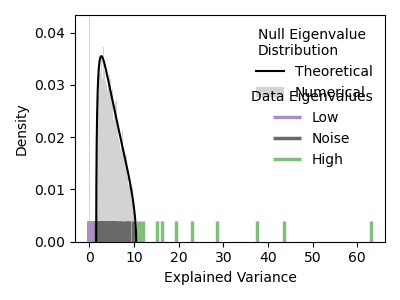

In [20]:
r = np.shape(cov_data)[1]/np.shape(cov_data)[0]
print('r={}'.format(r))
var=1.0 #as long as we consider data normalized by 1/std(x), such that we have a correlation matrix.
marchenko_pastur_min,marchenko_pastur_max = Marchenko_Pastur_significance_threshold(r,var)
eig_x_vector,marchenko_pastur_distr = Marchenko_Pastur_distribution(marchenko_pastur_min,marchenko_pastur_max,r,var)
print('lambda_min = {}'.format(marchenko_pastur_min))

'''
Plot Distribution of Eigenvalues of the Covariance Matrix
'''
plt.close('all')
%matplotlib widget
fig,ax = plt.subplots(figsize=(4,3))
counts,bins = np.histogram(random_eigvals,density=True,
                           # bins=150,
                           bins=int(np.sqrt(len(random_eigvals)))
                          )
dbin = bins[1]-bins[0]
bin_centers = bins[:-1]+dbin/2

final_restriction = -1 
prob_threshold = 0.21; check=False
cumulative_probabilities = []
for i,eig in enumerate(eigvals):
    which = (bin_centers-dbin/2<=eig)
    cumulative = np.array(np.cumsum(counts[which])*dbin)
    prob = 0
    if len(cumulative)!=0:
        prob = cumulative[-1]
        
        if prob>prob_threshold and check==False: final_restriction = i; check=True #we will only keep restrictions up to what is distinct from noise
    cumulative_probabilities.append(prob)
    # print('The prob. to find an eigenval smaller than {:.3f} \n in a random dataset is {:.3f}.'.format(eig,prob))

ax.bar(bin_centers[:],counts[:],
       width=dbin*1.02,edgecolor=None,
       zorder=0,color='lightgray',
      label='Numerical')
if how_many_experimental_samples<how_many_species_to_take:
    ax.bar(bin_centers[0],counts[0],
           facecolor='lightgray',
           width = dbin,edgecolor=None,zorder=0)
ax.plot(eig_x_vector,marchenko_pastur_distr,'k',label='Theoretical')
''' Plot the eigenvalues from the dataset '''
''' Eigenvalues are colored wrt the edge of the marchenko-pastur distribution
for visual effects, but the actual significance threshold is calculated in the cells below.'''
low_eigvals = eigvals[eigvals<marchenko_pastur_min]
high_eigvals = eigvals[eigvals>marchenko_pastur_max]
noise_eigvals = eigvals[(marchenko_pastur_min<= eigvals) & (eigvals <= marchenko_pastur_max)]
ax.vlines(low_eigvals,0,0.1*np.max(counts[1:]),colors=[175/255,141/255,195/255],
          linewidth=2.5,zorder=0,
         # label='Data (low)'
         )
ax.vlines(high_eigvals,0,0.1*np.max(counts[1:]),colors=[127/255,191/255,123/255],
          linewidth=2.5,zorder=0,
         # label='Data (high)'
         )
ax.vlines(noise_eigvals,0,0.1*np.max(counts[1:]),colors='dimgray',
          linewidth=2.5,zorder=0,
         # label='Data (noise)'
         )
plot_legend = True
if plot_legend:
    ax.legend(loc='upper right',frameon=False,
              title='Null Eigenvalue \nDistribution')
    ax2 = ax.twinx()
    ax2.set_axis_off()
    ax2.vlines(None,None,None,colors=[175/255,141/255,195/255],#'tab:red',
          linewidth=2.5,zorder=0,
         label='Low')
    ax2.vlines(None,None,None,colors='dimgray',#'tab:red',
          linewidth=2.5,zorder=0,
         label='Noise')
    ax2.vlines(None,None,None,colors=[127/255,191/255,123/255],#'tab:green',
          linewidth=2.5,zorder=0,
         label='High'
         )
    ax2.legend(loc = 'center right',frameon=False,
              title= 'Data Eigenvalues')
ax.set_xlabel('Explained Variance')
ax.set_ylabel('Density')
ax.set_ylim(bottom=0,top=np.max(counts[1:])*1.11)
# ax.set_xscale('log')
plt.tight_layout()
plt.savefig(os.path.join(out_figures,'eigenvalue_distribution.{}.png'.format(dataset_name)))
plt.savefig(os.path.join(out_figures,'eigenvalue_distribution.{}.svg'.format(dataset_name)),format='svg')


cumulative_probabilities = np.array(cumulative_probabilities)

## Determine statistically significant low- and high- variance modes.

### Remove eigenmodes due to rank defficiency.

If $M<N$, the correlation matrix is rank-defficent and has $M-1$ non-zero eigenvalues (that we keep) and $N-(M-1)$ exactly zero eigenvalues (that we discard).

In [21]:
how_many_nonzero_eigenvalues = min(M-1,N)
first_nonzero_eigenvalue = N-how_many_nonzero_eigenvalues #the +1 is from the projection
print('First non-zero eigenvalue:',first_nonzero_eigenvalue)
eigvects = eigvects[:,first_nonzero_eigenvalue:]
eigvals = eigvals[first_nonzero_eigenvalue:]

First non-zero eigenvalue: 450


In [22]:
'''
Build the distribution of extreme null eigenvalues (one for lowest, one for highest),
then compare empirical eigenvalues to these extreme distributions, with the 
chosen p-value.
'''
if include_rest_of_the_world: 
    N = N-1
inferred_number_randomizations = int(round(len(random_eigvals)/N)+0.001)

if inferred_number_randomizations != how_many_shuffles:
    print('The dummy eigenvalues can be divided into {} randomizations but the parameter "how many shuffles" is set to {}'.format(
        inferred_number_randomizations,how_many_shuffles))


if 'Estrella' in dataset_name or 'Goldford' in dataset_name:
    ''' If the '''
    print('Removing relative abundance mode from the null distribution')
    remove_compositional_mode = True
else:
    if N<M:
        print('OJO: not removing relative abundance mode and N<M. Check if ok.')
    else:
        print('OJO: not removing relative abundance mode. But N>M, so it should be ok.')
    remove_compositional_mode = False


lowest_eigval_null_distr = []
highest_eigval_null_distr = []
for rand in range(how_many_shuffles):
    nonzero_dummy_eigvals = np.sort(random_eigvals[rand*N:(rand+1)*N])[-(M-1):]
    if remove_compositional_mode:
        nonzero_dummy_eigvals = np.sort(nonzero_dummy_eigvals)[1:]
    lowest_eigval = np.min(nonzero_dummy_eigvals); highest_eigval = np.max(nonzero_dummy_eigvals)
    lowest_eigval_null_distr.append(lowest_eigval)
    highest_eigval_null_distr.append(highest_eigval)

lowest_eigval_null_distr = np.sort(np.array(lowest_eigval_null_distr)) #from smallest to largest
highest_eigval_null_distr = np.sort(np.array(highest_eigval_null_distr)) #from smalelst to largest

pval = 0.05 #choose a p-value of 0.05 on the extreme-value statistics.
significant_index = int(how_many_shuffles*pval)
low_eigval_threshold = lowest_eigval_null_distr[significant_index]
high_eigval_threshold = highest_eigval_null_distr[-(significant_index+1)]
print('Eigenvalue significance thresholds: \n',
      low_eigval_threshold,high_eigval_threshold)

if include_rest_of_the_world: N = N+1

OJO: not removing relative abundance mode. But N>M, so it should be ok.
Eigenvalue significance thresholds: 
 1.5076469477669239 10.688820615161546


In [23]:
small_eigvals = eigvals[eigvals<low_eigval_threshold]
large_eigvals = eigvals[eigvals>high_eigval_threshold]
low_variance_eigenmodes = eigvects[:,eigvals<low_eigval_threshold]
high_variance_eigenmodes = eigvects[:,eigvals>high_eigval_threshold]
noise_eigvals = eigvals[(eigvals>low_eigval_threshold)&(eigvals<high_eigval_threshold)]
noise_variance_eigenmodes = eigvects[:,(eigvals>low_eigval_threshold)&(eigvals<high_eigval_threshold)]


N_low = len(small_eigvals); N_high = len(large_eigvals); N_noise = len(noise_eigvals)

print('There are {} low and {} high variance modes'.format(N_low,N_high))

There are 35 low and 11 high variance modes


In [24]:
with open(os.path.join(out_dir,'high_variance_eigenmodes.{}.dat'.format(dataset_name)),'wb') as f:
    pickle.dump(high_variance_eigenmodes,f)
    f.close()
with open(os.path.join(out_dir,'high_variance_eigvals.{}.dat'.format(dataset_name)),'wb') as f:
    pickle.dump(large_eigvals,f)
    f.close()

with open(os.path.join(out_dir,'low_variance_eigvals.{}.dat'.format(dataset_name)),'wb') as f:
    pickle.dump(small_eigvals,f)
    f.close()
with open(os.path.join(out_dir,'low_variance_eigenmodes.{}.dat'.format(dataset_name)),'wb') as f:
    pickle.dump(low_variance_eigenmodes,f)
    f.close()

In [25]:
''' Load eigenmodes again. It's just a checkpoint, in case you want to skip doing the eigendecomposition and computing the null.'''
with open(os.path.join(out_dir,'high_variance_eigenmodes.{}.dat'.format(dataset_name)),'rb') as f:
    high_variance_eigenmodes = pickle.load(f)
    f.close()
with open(os.path.join(out_dir,'high_variance_eigvals.{}.dat'.format(dataset_name)),'rb') as f:
    large_eigvals = pickle.load(f)
    f.close()

with open(os.path.join(out_dir,'low_variance_eigvals.{}.dat'.format(dataset_name)),'rb') as f:
    small_eigvals = pickle.load(f)
    f.close()
with open(os.path.join(out_dir,'low_variance_eigenmodes.{}.dat'.format(dataset_name)),'rb') as f:
    low_variance_eigenmodes = pickle.load(f)
    f.close()

## Measure the similarity of LCs

To check whether they act on the same subset of taxa. If they do, then their fragility does not affect their sparsity.

KstestResult(statistic=0.5056806722689076, pvalue=5.016390587144717e-140, statistic_location=0.6122309137344502, statistic_sign=1)

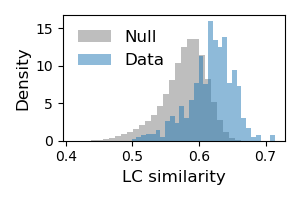

In [26]:
from scipy.stats import ks_2samp
''' Plot the similarity of eigenvectors '''

overlaps = []
for i in range(np.shape(low_variance_eigenmodes)[1]-1):
    vec1 = np.abs((low_variance_eigenmodes[:,i]))
    for j in range(i+1,np.shape(low_variance_eigenmodes)[1]):
        vec2 = np.abs((low_variance_eigenmodes[:,j]))

        overlap = np.dot(vec1,vec2) #the overlap is well-defined between 0 and 1 because abs(vect) still has norm 1.

        overlaps.append(overlap)

null_overlaps = []
for _ in range(100): #1 randomization for the activatedsludge dataset, 100 for the others.
    randomization = np.arange(np.shape(low_variance_eigenmodes)[1])
    np.random.shuffle(randomization)

    for i in range(np.shape(low_variance_eigenmodes)[1]-1):
        for j in range(i+1,np.shape(low_variance_eigenmodes)[1]):
            vec1 = np.abs((low_variance_eigenmodes[:,i]))
            np.random.shuffle(vec1)
            vec2 = np.abs((low_variance_eigenmodes[:,j]))
            np.random.shuffle(vec2)
        
            null_overlap = np.dot(vec1,vec2)
        
            null_overlaps.append(null_overlap)


fig,ax = plt.subplots(figsize=(3,2))
ax.hist(null_overlaps,density=True,bins=30,label='Null',
       facecolor='tab:gray',alpha=0.5)
ax.hist(overlaps,density=True,bins=30,label='Data',
       facecolor='tab:blue',alpha=0.5)
ax.legend(loc='best',frameon=False,fontsize=12)
# ax.set_xlabel(r'$\overrightarrow{|e|}_\alpha \cdot \overrightarrow{|e|}_\beta$',fontsize=12)
# ax.set_xlabel(r'$\sum_i \, |e_{i\alpha}| \cdot | e_{i\beta}|$',fontsize=12)
ax.set_xlabel('LC similarity',fontsize=12)
ax.set_ylabel('Density',fontsize=12)
plt.rcParams['xtick.labelsize']=10
plt.rcParams['ytick.labelsize']=10
plt.tight_layout()
plt.savefig(os.path.join(out_figures,'eigenmode_species_overlap.{}.png'.format(dataset_name)))
plt.savefig(os.path.join(out_figures,'eigenmode_species_overlap.{}.svg'.format(dataset_name)),format='svg',transparent=True)

ks_2samp(null_overlaps,
         overlaps,
        alternative='two-sided'
        )
    

    

Single out taxa with high contributions for visualization. We determine a taxon to be a high contributor if it is so with a p-value $<1/N$. If there are more than 30 taxa with high loadings, we keep only the highest 30 for the sake of visualization.

## Plot coupling matrix from strongest $J_{ij}$ couplings

And plot also the network corresponding to some of the low-variance modes, to see how they contribute to the couplings.

In [27]:
''' We will just compute the full MF matrix and the high+low matrix '''
new_gamma_full = np.zeros((N,N)) #Gamma = -J_couplings
new_gamma_both = np.zeros((N,N))
new_gamma_high = np.zeros((N,N))
new_gamma_low = np.zeros((N,N))
factor = r-1 if r>1 else 1
startindex = 0
if remove_compositional_mode == True: startindex = 1
    
for ii in range(startindex,len(eigvals)):
    if ii>=len(small_eigvals) and ii<len(eigvals)-len(large_eigvals):
        pass
    else:
        new_gamma_both += (factor/eigvals[ii]-1) *np.outer(eigvects[:,ii],eigvects[:,ii])
        if ii<len(small_eigvals):
            new_gamma_low += (factor/eigvals[ii]-1) *np.outer(eigvects[:,ii],eigvects[:,ii])
        else:
            new_gamma_high += (factor/eigvals[ii]-1) *np.outer(eigvects[:,ii],eigvects[:,ii])
    new_gamma_full += factor/eigvals[ii]*np.outer(eigvects[:,ii],eigvects[:,ii])

### FIll diagonals with 0, since we do not want to consider self-interactions
np.fill_diagonal(new_gamma_full,0)
np.fill_diagonal(new_gamma_both,0)
np.fill_diagonal(new_gamma_high,0)
np.fill_diagonal(new_gamma_low,0)

### Sort by strongest couplings
strongest_couplings = np.dstack(np.unravel_index(np.flip(np.argsort(np.abs(new_gamma_both).ravel())), np.shape(new_gamma_both)))[0]


# indices_CDF_significant_low  = np.unique(strongest_couplings[:N_couplings*2,0])
taxa_to_plot_in_network = min(30,N)
count = 0
indices_for_network = []
for index in strongest_couplings[:,0]: #edges are doubled like (a,b) then (b,a), so it's enough to read just the first indices.
    if index not in indices_for_network:
        indices_for_network.append(index)
        count += 1
    if count ==taxa_to_plot_in_network : #how many taxa to keep
        break 
indices_for_network = np.array(indices_for_network)


# indices_for_network = np.sort(important_taxa); taxa_to_plot_in_network = len(important_taxa)
# indices_for_network = np.random.choice(N,size=20,replace=False)
# indices_for_network = np.arange(20) #for most abundant taxa

abcd_argsorted_indices_for_network =  np.argsort(family_tags[indices_for_network],kind='stable')

new_gamma_full_all_indices = np.copy(new_gamma_full)
new_gamma_both_all_indices = np.copy(new_gamma_both)


''' reduce matrices to only the indices to be plotted '''
new_gamma_full = new_gamma_full[:,indices_for_network[abcd_argsorted_indices_for_network]][indices_for_network[abcd_argsorted_indices_for_network],:]
new_gamma_both = new_gamma_both[:,indices_for_network[abcd_argsorted_indices_for_network]][indices_for_network[abcd_argsorted_indices_for_network],:]
new_gamma_high = new_gamma_high[:,indices_for_network[abcd_argsorted_indices_for_network]][indices_for_network[abcd_argsorted_indices_for_network],:]
new_gamma_low = new_gamma_low[:,indices_for_network[abcd_argsorted_indices_for_network]][indices_for_network[abcd_argsorted_indices_for_network],:]

is min_w negative True
(3, 197)
['', '', '', '', '', '', '', 'f Oxalobacteraceae', '', '', 'f Xanthomonadaceae', '', '', '', '', '', 'g Paenibacillus', '', '', '', 'g Ralstonia', 'g Ralstonia', 'g Ralstonia', '', '', '', '', 'o Ellin5290', '', '']


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31168\2282413665.py:184: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm, shrink=0.5, pad=0.0)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31168\2282413665.py:193: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm,shrink=0.5,pad=0.0,location='bottom')


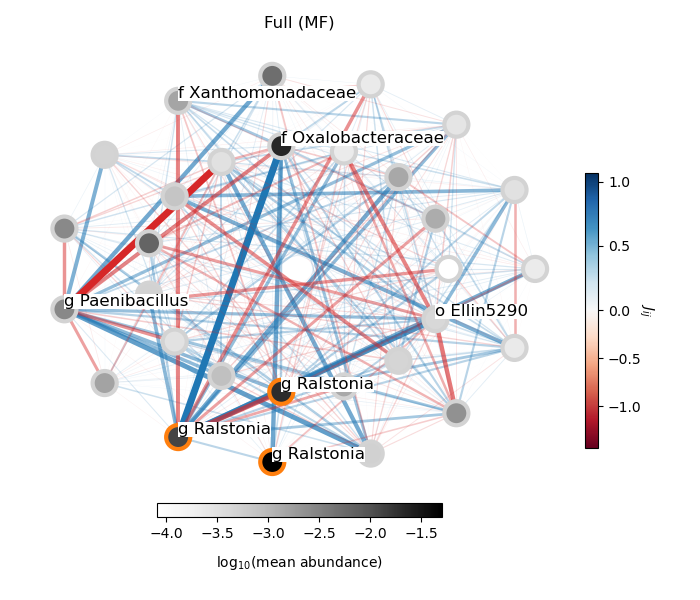

is min_w negative True
(3, 202)
['', '', '', '', '', '', '', 'f Oxalobacteraceae', '', '', 'f Xanthomonadaceae', '', '', '', '', '', 'g Paenibacillus', '', '', '', 'g Ralstonia', 'g Ralstonia', 'g Ralstonia', '', '', '', '', 'o Ellin5290', '', '']


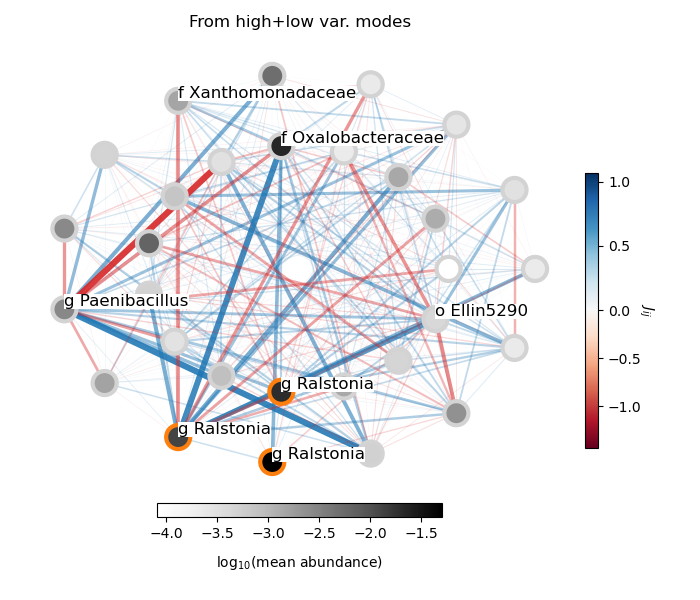

is min_w negative True
(3, 200)
['', '', '', '', '', '', '', 'f Oxalobacteraceae', '', '', 'f Xanthomonadaceae', '', '', '', '', '', 'g Paenibacillus', '', '', '', 'g Ralstonia', 'g Ralstonia', 'g Ralstonia', '', '', '', '', 'o Ellin5290', '', '']


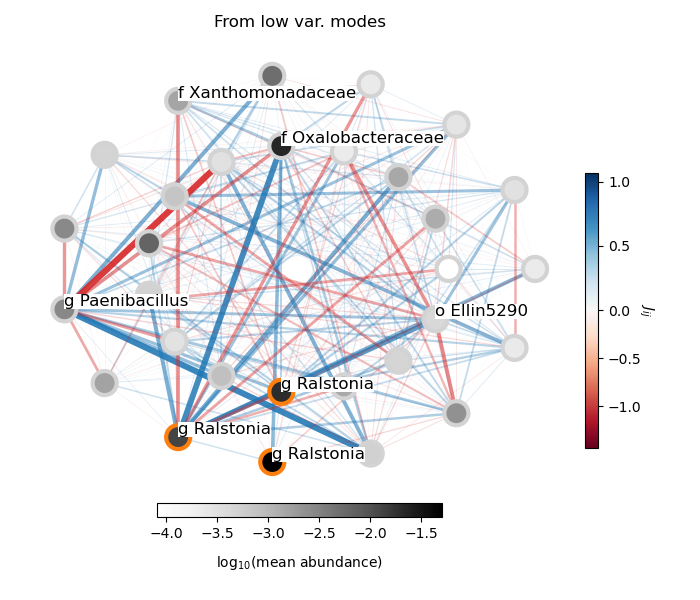

is min_w negative True
(3, 225)
['', '', '', '', '', '', '', 'f Oxalobacteraceae', '', '', 'f Xanthomonadaceae', '', '', '', '', '', 'g Paenibacillus', '', '', '', 'g Ralstonia', 'g Ralstonia', 'g Ralstonia', '', '', '', '', 'o Ellin5290', '', '']


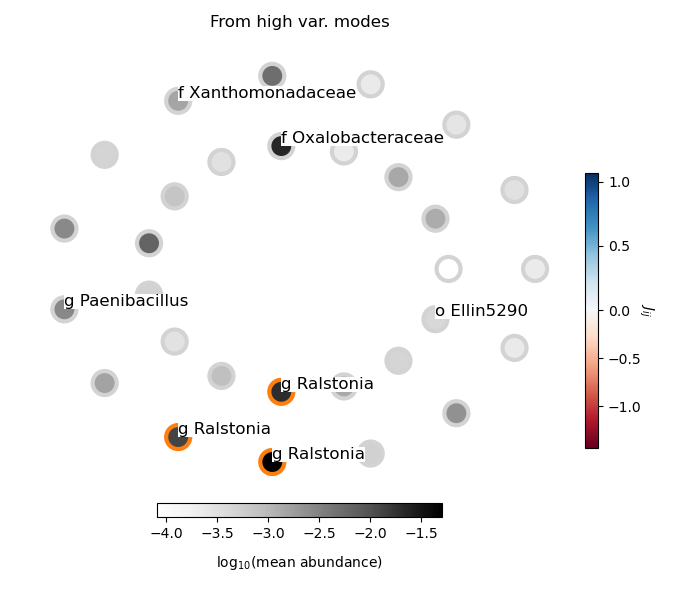

0.9840539143846262
is min_w negative True
(3, 211)


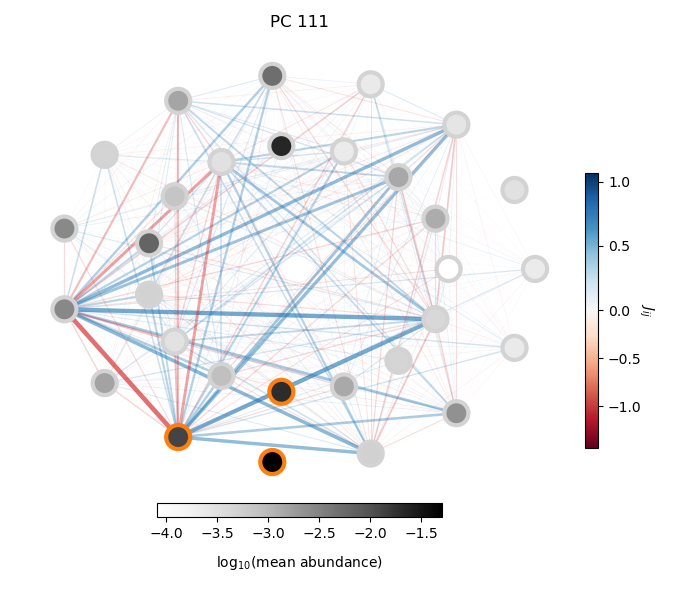

0.5633780250698254
is min_w negative True
(3, 214)


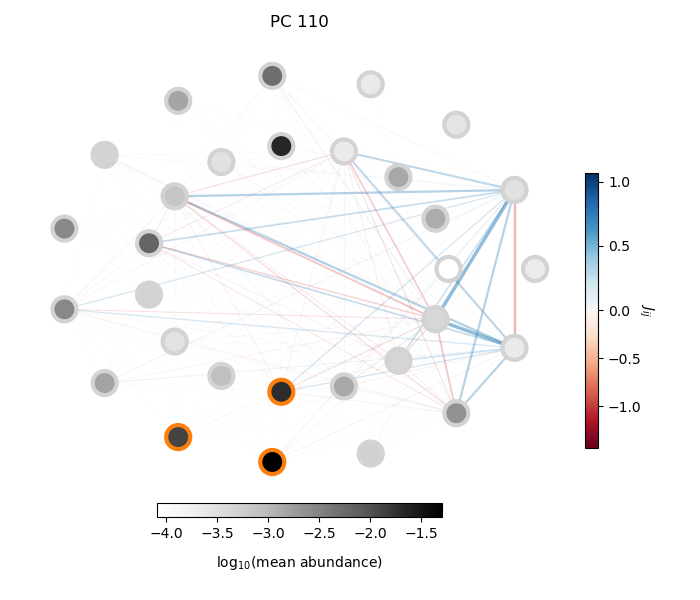

1.1630835239103205
is min_w negative True
(3, 214)


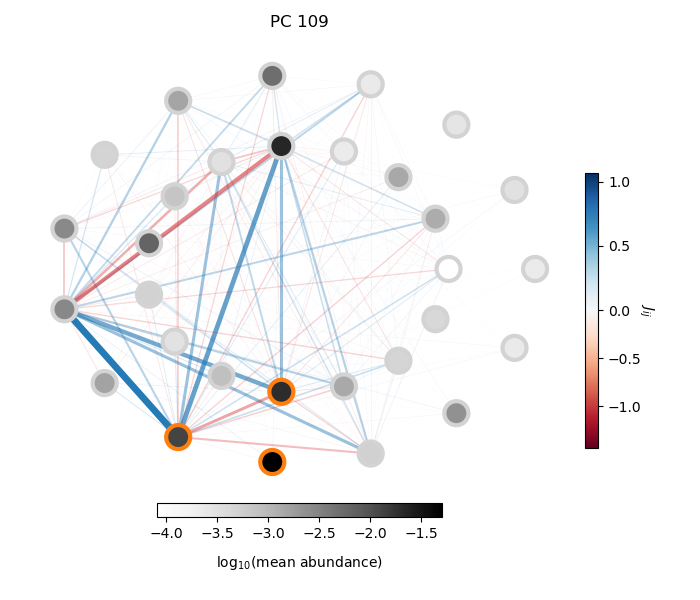

0.16420852437398883
is min_w negative True
(3, 210)


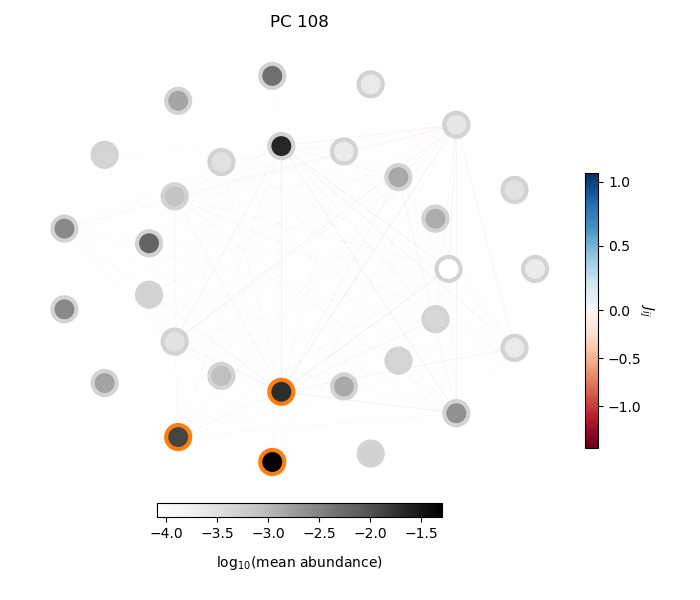

In [28]:
''' Plot Matrices '''
Jij_min = np.min((-new_gamma_full,-new_gamma_both))
Jij_max = np.max((-new_gamma_full,-new_gamma_both))
''' For Estrela '''
if 'Estrella' in dataset_name:
    if True:
        Jij_min = min(Jij_min,-1.5)
        Jij_max = max(Jij_max,1.5)
    else:
        Jij_min = -1.5 #min(Jij_min,-1.5)
        Jij_max = 1.5#max(Jij_max,1.5)

if dataset_name=='Grilli.Soil':
    ### For Soil dataset
    colored_labels_old_format = ['g__Ralstonia']
elif 'Grilli.GUT' in dataset_name:
    ### For Gut datasets
    colored_labels_old_format = ["g__[Prevotella]","g__Prevotella" , "s__copri","s__melaninogenica",'s__nanceiensis', 's__stercorea']
else:
    colored_labels_old_format = []


new_node_labels = []
if 'Grilli' in dataset_name:
    ''' Label only the colored_labels strains and those that they interact strongest with '''
    how_many_contacts = 3 #the number of strong contacts to select, per species
    strongest_couplings = []
    for ii,label in enumerate(family_tags):
        if label in colored_labels_old_format:
            J_taxon = np.abs(new_gamma_both_all_indices[ii,:]) #couplings between given taxon and all others
            argsorted = np.flip(np.argsort(J_taxon)) #sorted in decreasing value
            for s in argsorted[:how_many_contacts]: strongest_couplings.append(s) #append the index identities of the strongest coupled taxa to the current taxon.
    strongest_couplings = np.unique(strongest_couplings) #indices are wrt the complete community, not the indices_for_network
    new_indices_for_network = []
    for i in indices_for_network: #amongst those with strongest J_ij in the network
            if (i in strongest_couplings) or (family_tags[i] in colored_labels_old_format): #and is, or is strongly connected to, the selected taxa.
                new_node_labels.append(family_tags[i])
            else:
                new_node_labels.append('')
    new_node_labels = np.array(new_node_labels)
    new_node_labels = new_node_labels[abcd_argsorted_indices_for_network]
    node_labels = new_node_labels
else:
    ''' Node labels are all indices_for_network '''
    node_labels = [label for label in family_tags[indices_for_network][abcd_argsorted_indices_for_network]]
    
node_labels = [label.replace('__','_') for label in node_labels]
node_labels = [label.replace('_',' ') for label in node_labels]
node_labels = [label[:] for label in node_labels]
for ii,label in enumerate(node_labels):
    if ii>=taxa_to_plot_in_network: 
        node_labels[ii] = ''




if dataset_name=='Grilli.Soil':
    ### For Soil dataset
    colored_labels = ['g Ralstonia']
elif 'Grilli.GUT' in dataset_name:
    ### For Gut datasets
    colored_labels = ["g [Prevotella]","g Prevotella" , "s copri","s melaninogenica",'s nanceiensis', 's stercorea']
else:
    colored_labels = []

mean_abus = cov_data_means[indices_for_network[abcd_argsorted_indices_for_network]]
mean_abus = mean_abus

plt.close('all')
plot_weighted_graph(-new_gamma_full,node_labels = node_labels,dataset_name = dataset_name,
                    minvalue = Jij_min,maxvalue =Jij_max,
                    colored_labels = colored_labels,
                    node_sizes = mean_abus,
                   figtitle = 'Full (MF)',node_size_with_mean_abundance=False,
                   figname='MF_interaction_network') 

plot_weighted_graph(-new_gamma_both,node_labels = node_labels,dataset_name = dataset_name,
                    minvalue = Jij_min,maxvalue =Jij_max,
                    colored_labels = colored_labels,
                    node_sizes = mean_abus,
                   figtitle = 'From high+low var. modes',node_size_with_mean_abundance=False,
                   figname='high_low_interaction_network') 
plot_weighted_graph(-new_gamma_low,node_labels = node_labels,dataset_name = dataset_name,
                    minvalue = Jij_min,maxvalue =Jij_max,
                    colored_labels = colored_labels,
                    node_sizes = mean_abus,
                   figtitle = 'From low var. modes',node_size_with_mean_abundance=False,
                   figname='low_interaction_network') 
plot_weighted_graph(-new_gamma_high,node_labels = node_labels,dataset_name = dataset_name,
                    minvalue = Jij_min,maxvalue =Jij_max,
                    colored_labels = colored_labels,
                    node_sizes = mean_abus,
                   figtitle = 'From high var. modes',node_size_with_mean_abundance=False,
                   figname='high_interaction_network') 


for ii in range(startindex,4): #range(-2,-0):
# for ii in range(-2,-0):
    single_vector_contribution = (factor/eigvals[ii]-1) *np.outer(eigvects[:,ii],eigvects[:,ii])
    ''' Get indices to be plotted '''
    single_vector_contribution =single_vector_contribution[:,indices_for_network[abcd_argsorted_indices_for_network]][indices_for_network[abcd_argsorted_indices_for_network],:]

    print(np.max(single_vector_contribution))
    plot_weighted_graph(-single_vector_contribution,
                        node_labels = node_labels,write_labels = False,dataset_name = dataset_name,
                    minvalue = Jij_min,maxvalue =Jij_max,
                    colored_labels = colored_labels,
                    node_sizes = mean_abus,
                   figtitle = 'PC {}'.format(len(eigvals)-ii),node_size_with_mean_abundance=False,
                    figname = 'PC{}_interaction_network'.format(len(eigvals)-ii))
    



## Further data-visualization analyses

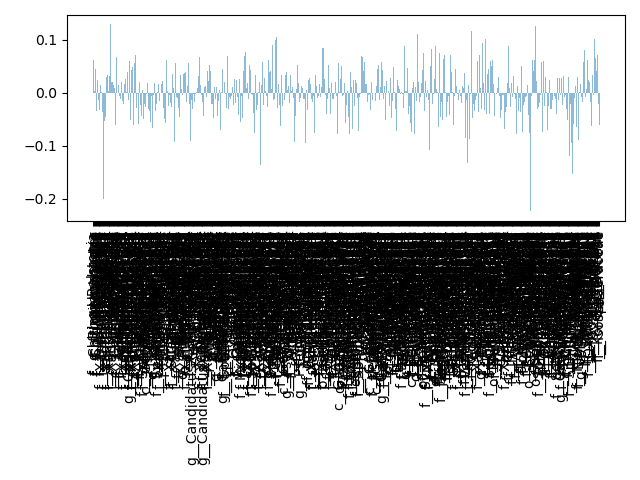

In [29]:
''' Plot Eigenvector. '''
fig,ax = plt.subplots()
which_mode = 4 #LCs start from 0. If plotting PCs, I reccomend starting from -1.
eigvect = eigvects[:,which_mode]
ax.bar(range(N),
       eigvect,alpha=0.5,
       width=1)
ax.set_xticks(range(len(family_tags)))
ax.set_xticklabels(family_tags,rotation=90)
plt.tight_layout()

### See if a chosen coarse-graining method shows a significantly small variance

In [30]:
vector = []
for tag in family_tags:
    if 'Pseudom' in tag:
        vector.append(0.5)
    elif 'Enterob' in tag:
        vector.append(-1)
    else:
        vector.append(0)

vector = vector*cov_data_stds #so that it's good for z-scores
vector = vector/np.sqrt(np.sum(vector**2))

In [31]:
c_vector = np.linalg.inv(eigvects) @ vector

LinAlgError: Last 2 dimensions of the array must be square

In [ ]:
vector_proj_var = np.var(cov_data@vector)

In [ ]:
print(marchenko_pastur_min)
print(vector_proj_var)
print('Is the projection on the chosen vector smaller than lam_minus of the MP?', vector_proj_var<marchenko_pastur_min)

In [ ]:
fig,ax = plt.subplots()
ax.bar(np.arange(N),
       c_vector**2,
       width=1)
ax.set_xlabel('Eigenmode')
ax.set_ylabel('Contribution to chosen coarse-graining')

In [ ]:
vector